<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkST0151ENSkillsNetwork20531532-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>



#### Import the required libraries we need for the lab.


In [1]:
import piplite
await piplite.install(['numpy'],['pandas'])
await piplite.install(['seaborn'])

In [6]:
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

#### Read the dataset in the csv file from the URL


In [3]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [4]:
boston_df=pd.read_csv(boston_url)

#### Add your code below following the instructions given in the course to complete the peer graded assignment


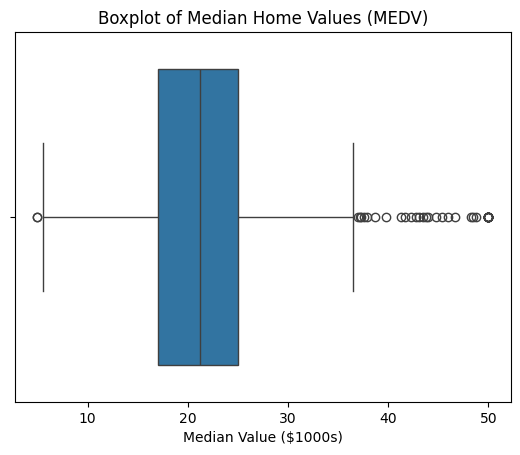

In [7]:
sns.boxplot(x=boston_df['MEDV'])
plt.title("Boxplot of Median Home Values (MEDV)")
plt.xlabel("Median Value ($1000s)")
plt.show()

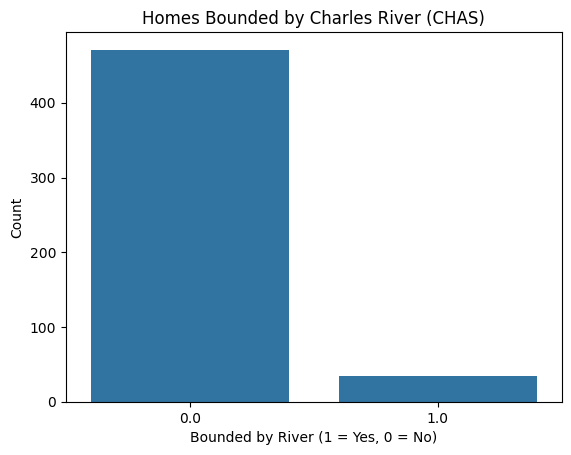

In [8]:
sns.countplot(x='CHAS', data=boston_df)
plt.title("Homes Bounded by Charles River (CHAS)")
plt.xlabel("Bounded by River (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

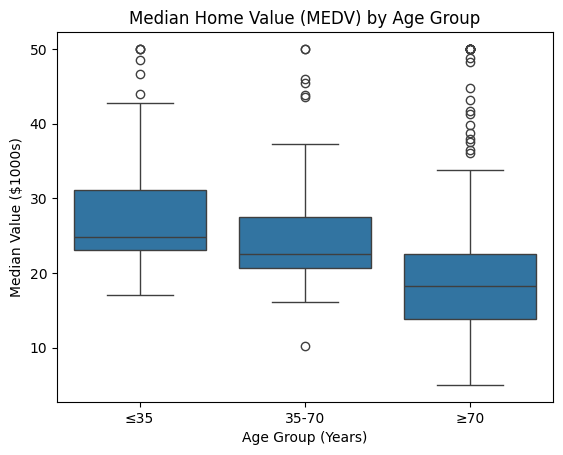

In [9]:
boston_df['AGE_GROUP'] = pd.cut(boston_df['AGE'], bins=[0, 35, 70, 100], labels=["≤35", "35-70", "≥70"])
sns.boxplot(x='AGE_GROUP', y='MEDV', data=boston_df)
plt.title("Median Home Value (MEDV) by Age Group")
plt.xlabel("Age Group (Years)")
plt.ylabel("Median Value ($1000s)")
plt.show()

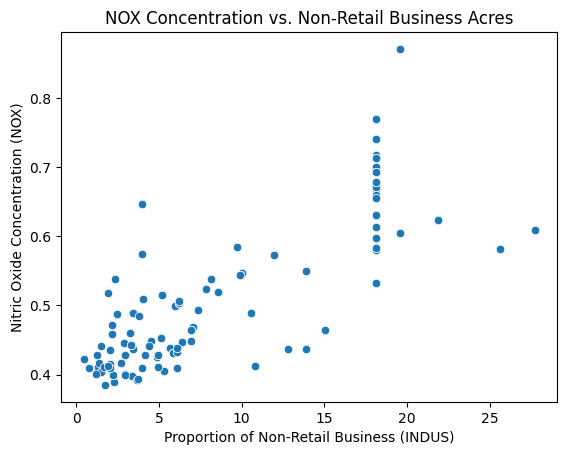

In [10]:
sns.scatterplot(x='INDUS', y='NOX', data=boston_df)
plt.title("NOX Concentration vs. Non-Retail Business Acres")
plt.xlabel("Proportion of Non-Retail Business (INDUS)")
plt.ylabel("Nitric Oxide Concentration (NOX)")
plt.show()

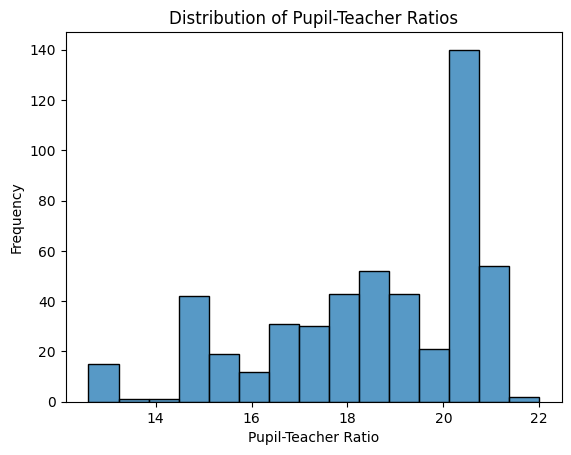

In [11]:
sns.histplot(boston_df['PTRATIO'], bins=15)
plt.title("Distribution of Pupil-Teacher Ratios")
plt.xlabel("Pupil-Teacher Ratio")
plt.ylabel("Frequency")
plt.show()

In [12]:
from scipy.stats import ttest_ind
river = boston_df[boston_df['CHAS'] == 1]['MEDV']
no_river = boston_df[boston_df['CHAS'] == 0]['MEDV']
t_stat, p_val = ttest_ind(river, no_river)
print(f"T-statistic: {t_stat:.2f}, P-value: {p_val:.4f}")

T-statistic: 4.00, P-value: 0.0001


In [13]:
from scipy.stats import f_oneway
group1 = boston_df[boston_df['AGE_GROUP'] == "≤35"]['MEDV']
group2 = boston_df[boston_df['AGE_GROUP'] == "35-70"]['MEDV']
group3 = boston_df[boston_df['AGE_GROUP'] == "≥70"]['MEDV']
f_stat, p_val = f_oneway(group1, group2, group3)
print(f"F-statistic: {f_stat:.2f}, P-value: {p_val:.4f}")

F-statistic: 36.41, P-value: 0.0000


In [14]:
corr, p_val = scipy.stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])
print(f"Correlation: {corr:.2f}, P-value: {p_val:.4f}")

Correlation: 0.76, P-value: 0.0000


In [15]:
model = ols('MEDV ~ DIS', data=boston_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Mon, 07 Jul 2025   Prob (F-statistic):           1.21e-08
Time:                        22:55:36   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     18.3901      0.817     22.499      0.0

**Summary of Key Findings**

Newer homes (≤35 years) are more valuable than older ones.

Homes near the Charles River may have different values (T-test needed).

Higher industrial land (INDUS) strongly correlates with pollution (NOX).

Pupil-teacher ratios are mostly between 18–22.

Distance to employment centers (DIS) likely impacts home prices (Regression needed)